<center>
<img src="https://laelgelcpublic.s3.sa-east-1.amazonaws.com/lael_50_years_narrow_white.png.no_years.400px_96dpi.png" width="300" alt="LAEL 50 years logo">
<h3>APPLIED LINGUISTICS GRADUATE PROGRAMME (LAEL)</h3>
</center>
<hr>

# Corpus Linguistics - Study 2 - Phase 3 - Elaine

This phase aims at:

- Compiling the target corpus for a pilot Lexical Multi-Dimensional Analysis.

## Prerequisites

Make sure the prerequisites in [CL_LMDA_prerequisites](https://github.com/laelgelc/laelgelc/blob/main/CL_LMDA_prerequisites.ipynb) are satisfied.

## Required Python packages

- pandas
- numpy
- seaborn
- matplotlib

## Import the required libraries

In [1]:
import os
import sys
import pandas as pd
import re
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Define input variables

In [2]:
input_directory = 'cl_st2_ph3_elaine'
output_directory = 'cl_st2_ph3_elaine'
dataset_filename_2 = 'cl_st2_ph3_elaine_dataset'
dataset_filename_3 = 'cl_st2_ph3_elaine_tc'

## Create output directory

In [3]:
# Check if the output directory already exists. If it does, do nothing. If it doesn't exist, create it.
if os.path.exists(output_directory):
    print('Output directory already exists.')
else:
    try:
        os.makedirs(output_directory)
        print('Output directory successfully created.')
    except OSError as e:
        print('Failed to create the directory:', e)
        sys.exit(1)

Output directory already exists.


## Import the data into a DataFrame

In [4]:
df_ted = pd.read_json(f'{input_directory}/{dataset_filename_2}.jsonl', lines=True)

In [5]:
df_ted

,Root Directory,File,File Path,Text ID,Year,Word Count NLTK,Text
0,CoTED2_TED_TEDEX_1984_2025,T0004_AM_TED_2019.txt,CoTED2_TED_TEDEX_1984_2025/T0004_AM_TED_2019.txt,t000000,2019,2507,I spent the past three years talking to some o...
1,CoTED2_TED_TEDEX_1984_2025,T0006_AV_TED_2019.txt,CoTED2_TED_TEDEX_1984_2025/T0006_AV_TED_2019.txt,t000001,2019,1115,[This is an improvised talk (and intro) based ...
2,CoTED2_TED_TEDEX_1984_2025,T0007_AAB_TED_2019.txt,CoTED2_TED_TEDEX_1984_2025/T0007_AAB_TED_2019.txt,t000002,2019,1734,So one of the most important solutions to the ...
3,CoTED2_TED_TEDEX_1984_2025,T0008_BV_TED_2019.txt,CoTED2_TED_TEDEX_1984_2025/T0008_BV_TED_2019.txt,t000003,2019,1736,"So in the winter of 2012, I went to visit my g..."
4,CoTED2_TED_TEDEX_1984_2025,T0009_BW_TED_RES_2019.txt,CoTED2_TED_TEDEX_1984_2025/T0009_BW_TED_RES_20...,t000004,2019,1223,For all that's ever been said about climate ch...
...,...,...,...,...,...,...,...
4310,CoTED2_TED_TEDEX_1984_2025,T5897_CH_TED_TWWW_2020.txt,CoTED2_TED_TEDEX_1984_2025/T5897_CH_TED_TWWW_2...,t004312,2020,963,I was not one of those kids that knew exactly ...
4311,CoTED2_TED_TEDEX_1984_2025,T5898_EO_TED_TWWW_2020.txt,CoTED2_TED_TEDEX_1984_2025/T5898_EO_TED_TWWW_2...,t004313,2020,1071,"When I was pregnant, I just got very frustrate..."
4312,CoTED2_TED_TEDEX_1984_2025,T5899_TD_TED_TWWW_2020.txt,CoTED2_TED_TEDEX_1984_2025/T5899_TD_TED_TWWW_2...,t004314,2020,752,When you think about money and your dreams and...
4313,CoTED2_TED_TEDEX_1984_2025,T5900_LR_TED_TWWW_2020.txt,CoTED2_TED_TEDEX_1984_2025/T5900_LR_TED_TWWW_2...,t004315,2020,920,"If you look at a carpenter, they have a toolbo..."


In [6]:
df_ted.dtypes

Root Directory     object
File               object
File Path          object
Text ID            object
Year                int64
Word Count NLTK     int64
Text               object
dtype: object

## Data wrangling

### Drop short paragraphs

#### Shorter than 10 words

In [7]:
mask_short = df_ted['Word Count NLTK'] <= 10
df_short_paragraphs = df_ted.loc[mask_short, ['Text']]
df_short_paragraphs

,Text


#### Drop the paragraphs

In [8]:
# Drop rows from df_ted where mask_short is True
initial_count = len(df_ted)
removed_count = int(mask_short.sum())

df_ted = df_ted.loc[~mask_short].reset_index(drop=True)

print(f"Dropped {removed_count} short paragraphs; remaining rows: {len(df_ted)}")
df_ted

Dropped 0 short paragraphs; remaining rows: 4315


,Root Directory,File,File Path,Text ID,Year,Word Count NLTK,Text
0,CoTED2_TED_TEDEX_1984_2025,T0004_AM_TED_2019.txt,CoTED2_TED_TEDEX_1984_2025/T0004_AM_TED_2019.txt,t000000,2019,2507,I spent the past three years talking to some o...
1,CoTED2_TED_TEDEX_1984_2025,T0006_AV_TED_2019.txt,CoTED2_TED_TEDEX_1984_2025/T0006_AV_TED_2019.txt,t000001,2019,1115,[This is an improvised talk (and intro) based ...
2,CoTED2_TED_TEDEX_1984_2025,T0007_AAB_TED_2019.txt,CoTED2_TED_TEDEX_1984_2025/T0007_AAB_TED_2019.txt,t000002,2019,1734,So one of the most important solutions to the ...
3,CoTED2_TED_TEDEX_1984_2025,T0008_BV_TED_2019.txt,CoTED2_TED_TEDEX_1984_2025/T0008_BV_TED_2019.txt,t000003,2019,1736,"So in the winter of 2012, I went to visit my g..."
4,CoTED2_TED_TEDEX_1984_2025,T0009_BW_TED_RES_2019.txt,CoTED2_TED_TEDEX_1984_2025/T0009_BW_TED_RES_20...,t000004,2019,1223,For all that's ever been said about climate ch...
...,...,...,...,...,...,...,...
4310,CoTED2_TED_TEDEX_1984_2025,T5897_CH_TED_TWWW_2020.txt,CoTED2_TED_TEDEX_1984_2025/T5897_CH_TED_TWWW_2...,t004312,2020,963,I was not one of those kids that knew exactly ...
4311,CoTED2_TED_TEDEX_1984_2025,T5898_EO_TED_TWWW_2020.txt,CoTED2_TED_TEDEX_1984_2025/T5898_EO_TED_TWWW_2...,t004313,2020,1071,"When I was pregnant, I just got very frustrate..."
4312,CoTED2_TED_TEDEX_1984_2025,T5899_TD_TED_TWWW_2020.txt,CoTED2_TED_TEDEX_1984_2025/T5899_TD_TED_TWWW_2...,t004314,2020,752,When you think about money and your dreams and...
4313,CoTED2_TED_TEDEX_1984_2025,T5900_LR_TED_TWWW_2020.txt,CoTED2_TED_TEDEX_1984_2025/T5900_LR_TED_TWWW_2...,t004315,2020,920,"If you look at a carpenter, they have a toolbo..."


### Drop duplicate paragraphs

#### Identify duplicate paragraphs

In [9]:
mask_dupes = df_ted['Text'].notna() & df_ted['Text'].duplicated(keep=False)
df_ted.loc[mask_dupes, ['Text']].sort_values('Text')

,Text


#### Drop the paragraphs

In [10]:
# Drop duplicate paragraphs, keeping the first occurrence
mask_drop_dupes = df_ted['Text'].duplicated(keep='first')
removed_dupes = int(mask_drop_dupes.sum())

df_ted = df_ted.loc[~mask_drop_dupes].reset_index(drop=True)

print(f"Dropped {removed_dupes} duplicate paragraphs; remaining rows: {len(df_ted)}")
df_ted

Dropped 0 duplicate paragraphs; remaining rows: 4315


,Root Directory,File,File Path,Text ID,Year,Word Count NLTK,Text
0,CoTED2_TED_TEDEX_1984_2025,T0004_AM_TED_2019.txt,CoTED2_TED_TEDEX_1984_2025/T0004_AM_TED_2019.txt,t000000,2019,2507,I spent the past three years talking to some o...
1,CoTED2_TED_TEDEX_1984_2025,T0006_AV_TED_2019.txt,CoTED2_TED_TEDEX_1984_2025/T0006_AV_TED_2019.txt,t000001,2019,1115,[This is an improvised talk (and intro) based ...
2,CoTED2_TED_TEDEX_1984_2025,T0007_AAB_TED_2019.txt,CoTED2_TED_TEDEX_1984_2025/T0007_AAB_TED_2019.txt,t000002,2019,1734,So one of the most important solutions to the ...
3,CoTED2_TED_TEDEX_1984_2025,T0008_BV_TED_2019.txt,CoTED2_TED_TEDEX_1984_2025/T0008_BV_TED_2019.txt,t000003,2019,1736,"So in the winter of 2012, I went to visit my g..."
4,CoTED2_TED_TEDEX_1984_2025,T0009_BW_TED_RES_2019.txt,CoTED2_TED_TEDEX_1984_2025/T0009_BW_TED_RES_20...,t000004,2019,1223,For all that's ever been said about climate ch...
...,...,...,...,...,...,...,...
4310,CoTED2_TED_TEDEX_1984_2025,T5897_CH_TED_TWWW_2020.txt,CoTED2_TED_TEDEX_1984_2025/T5897_CH_TED_TWWW_2...,t004312,2020,963,I was not one of those kids that knew exactly ...
4311,CoTED2_TED_TEDEX_1984_2025,T5898_EO_TED_TWWW_2020.txt,CoTED2_TED_TEDEX_1984_2025/T5898_EO_TED_TWWW_2...,t004313,2020,1071,"When I was pregnant, I just got very frustrate..."
4312,CoTED2_TED_TEDEX_1984_2025,T5899_TD_TED_TWWW_2020.txt,CoTED2_TED_TEDEX_1984_2025/T5899_TD_TED_TWWW_2...,t004314,2020,752,When you think about money and your dreams and...
4313,CoTED2_TED_TEDEX_1984_2025,T5900_LR_TED_TWWW_2020.txt,CoTED2_TED_TEDEX_1984_2025/T5900_LR_TED_TWWW_2...,t004315,2020,920,"If you look at a carpenter, they have a toolbo..."


### Determine the `Paragraph Count` per `Document Type`

In [19]:
df_texts_per_year = (
    df_ted
    .groupby('Year', dropna=False)
    .size()
    .reset_index(name='Text Count')
    .sort_values(['Year'], ascending=[True])
    .reset_index(drop=True)
)
df_texts_per_year

,Year,Text Count
0,1984,1
1,1990,1
2,1994,1
3,1998,6
4,2001,4
5,2002,25
6,2003,31
7,2004,30
8,2005,61
9,2006,41


### Export to a file

In [21]:
df_ted.to_json(f"{output_directory}/{dataset_filename_3}.jsonl", orient='records', lines=True)

In [22]:
df_ted.to_excel(f"{output_directory}/{dataset_filename_3}.xlsx", index=False)

## Import the Target Corpus into a DataFrame

In [4]:
df_ted_tc = pd.read_json(f"{output_directory}/{dataset_filename_3}.jsonl", lines=True)

In [5]:
df_ted_tc

,Root Directory,File,File Path,Text ID,Year,Word Count NLTK,Text
0,CoTED2_TED_TEDEX_1984_2025,T0004_AM_TED_2019.txt,CoTED2_TED_TEDEX_1984_2025/T0004_AM_TED_2019.txt,t000000,2019,2507,I spent the past three years talking to some o...
1,CoTED2_TED_TEDEX_1984_2025,T0006_AV_TED_2019.txt,CoTED2_TED_TEDEX_1984_2025/T0006_AV_TED_2019.txt,t000001,2019,1115,[This is an improvised talk (and intro) based ...
2,CoTED2_TED_TEDEX_1984_2025,T0007_AAB_TED_2019.txt,CoTED2_TED_TEDEX_1984_2025/T0007_AAB_TED_2019.txt,t000002,2019,1734,So one of the most important solutions to the ...
3,CoTED2_TED_TEDEX_1984_2025,T0008_BV_TED_2019.txt,CoTED2_TED_TEDEX_1984_2025/T0008_BV_TED_2019.txt,t000003,2019,1736,"So in the winter of 2012, I went to visit my g..."
4,CoTED2_TED_TEDEX_1984_2025,T0009_BW_TED_RES_2019.txt,CoTED2_TED_TEDEX_1984_2025/T0009_BW_TED_RES_20...,t000004,2019,1223,For all that's ever been said about climate ch...
...,...,...,...,...,...,...,...
4310,CoTED2_TED_TEDEX_1984_2025,T5897_CH_TED_TWWW_2020.txt,CoTED2_TED_TEDEX_1984_2025/T5897_CH_TED_TWWW_2...,t004312,2020,963,I was not one of those kids that knew exactly ...
4311,CoTED2_TED_TEDEX_1984_2025,T5898_EO_TED_TWWW_2020.txt,CoTED2_TED_TEDEX_1984_2025/T5898_EO_TED_TWWW_2...,t004313,2020,1071,"When I was pregnant, I just got very frustrate..."
4312,CoTED2_TED_TEDEX_1984_2025,T5899_TD_TED_TWWW_2020.txt,CoTED2_TED_TEDEX_1984_2025/T5899_TD_TED_TWWW_2...,t004314,2020,752,When you think about money and your dreams and...
4313,CoTED2_TED_TEDEX_1984_2025,T5900_LR_TED_TWWW_2020.txt,CoTED2_TED_TEDEX_1984_2025/T5900_LR_TED_TWWW_2...,t004315,2020,920,"If you look at a carpenter, they have a toolbo..."


### Identify occurrences of the `pipe` character in the `Text Paragraph` column

Further on, a few columns of the DataFrame are going to be exported into the file `tweets.txt` whose columns need to be delimited by the `pipe` character. Therefore, it is recommended that any occurrences of the `pipe` character in the `Text Paragraph` column are replaced by another character.

In [6]:
mask_pipe = df_ted_tc['Text'].str.contains(r'\|', na=False)
df_with_pipe = df_ted_tc.loc[mask_pipe, ['Text']]
df_with_pipe

,Text
3319,The ways of the world often baffle me. I somet...


In [7]:
# Defining a function to replace the 'pipe' character by the '-' character
def replace_pipe_with_hyphen(input_string):
    modified_string = re.sub(r'\|', '-', input_string)
    return modified_string

# Replacing the 'pipe' character by the '-' character
df_ted_tc['Text'] = df_ted_tc['Text'].apply(replace_pipe_with_hyphen)

## Identify markers of audience reaction

In [8]:
# Task: From df_ted_tc, extract all substrings enclosed in parentheses in the Text column,
# and create a set of unique phrases (including the parentheses).

# Ensure required imports are available (re already imported earlier in the notebook)
#import re

# Ensure df_ted_tc exists with a 'Text' column
if 'df_ted_tc' in globals() and isinstance(df_ted_tc, pd.DataFrame) and 'Text' in df_ted_tc.columns:
    # Regex to capture non-greedy content between parentheses, handling multiple per row
    pattern = re.compile(r'\([^()]*\)')
    # Extract lists of matches per row (skip NaN safely), then flatten
    all_paren_phrases = (
        df_ted_tc['Text']
        .dropna()
        .astype(str)
        .apply(pattern.findall)
        .explode()
        .dropna()
        .tolist()
    )
    phrases_in_parentheses = set(all_paren_phrases)

    print(f"Unique parenthetical phrases found: {len(phrases_in_parentheses)}")
else:
    phrases_in_parentheses = set()
    print("df_ted_tc with column 'Text' is not available.")

# Optionally preview a few items deterministically
#preview = sorted(list(phrases_in_parentheses))[:20]
#preview

Unique parenthetical phrases found: 1321


In [9]:
# Export the `phrases_in_parentheses` set into a text file, one phrase per line.
# Assumes `phrases_in_parentheses` already exists in the notebook context.

export_path = os.path.join(output_directory if 'output_directory' in globals() else '.', 'phrases_in_parentheses.txt')

with open(export_path, 'w', encoding='utf-8', newline='\n') as f:
    for phrase in sorted(phrases_in_parentheses):
        f.write(f"{phrase}\n")

print(f"Exported {len(phrases_in_parentheses)} phrases to {export_path}")

Exported 1321 phrases to cl_st2_ph3_elaine/phrases_in_parentheses.txt


In [10]:
# Task: From the existing `phrases_in_parentheses` set, build a DataFrame with counts
# and export it as JSON.

# Ensure required imports are available (pandas and os already imported earlier in the notebook)
#import pandas as pd
#import os

# Validate source set
if 'phrases_in_parentheses' in globals() and isinstance(phrases_in_parentheses, set):
    # We also need counts per phrase from the original list of occurrences
    if 'all_paren_phrases' in globals() and isinstance(all_paren_phrases, list):
        # Build counts using pandas
        s = pd.Series(all_paren_phrases, dtype="string").dropna()
        df_phrases_in_parentheses = (
            s.value_counts()
            .rename_axis('Phrases in Parentheses')
            .reset_index(name='Count')
        )
    else:
        # Fall back: create counts = 1 for each unique phrase if the full list isn't available
        df_phrases_in_parentheses = pd.DataFrame(
            {'Phrases in Parentheses': sorted(list(phrases_in_parentheses)),
             'Count': 1}
        )
else:
    # Empty fallback
    df_phrases_in_parentheses = pd.DataFrame(
        {'Phrases in Parentheses': pd.Series(dtype="string"),
         'Count': pd.Series(dtype="int")}
    )

# Preview
df_phrases_in_parentheses

# Export to JSON (records)
export_json_path = os.path.join(output_directory if 'output_directory' in globals() else '.',
                                'phrases_in_parentheses_counts.json')
df_phrases_in_parentheses.to_json(export_json_path, orient='records', force_ascii=False)
print(f"Exported df_phrases_in_parentheses to {export_json_path} with {len(df_phrases_in_parentheses)} rows.")

Exported df_phrases_in_parentheses to cl_st2_ph3_elaine/phrases_in_parentheses_counts.json with 1321 rows.


After examining the phrases in parentheses, we proceed to tokenise the text without considering the markers of audience reaction.

## Tokenise.

## Tokenise

Please refer to [What is tokenization in NLP?](https://www.analyticsvidhya.com/blog/2020/05/what-is-tokenization-nlp/).

### Inspect one row

In [52]:
print(df_ted_tc.at[3319, 'Text'])

The ways of the world often baffle me. I sometimes wonder if I missed the memo about the most basic things. What are you supposed to make for dinner? What do you talk about in an elevator? Why do people cut in line? How do you leave a dinner party without being rude? Or do you leave it all? ["Why are you still here?"] (Laughter) My tendency to see the world like I'm from outer space was a bit of a liability when I was a kid. True story. ["What's a noogie?"] (Laughter) But it's been helpful in my career. I'm a cartoonist. When I first started making cartoons for The New Yorker about a decade ago, I kept my ideas light and quirky. And please shout out if you don't get any of them, I'll explain. (Laughter) ["The synchronized swim team quits"] I didn't draw anything too personal. ["Unicorns do exist!"] I mean, personal for someone. I figured I was too specific, too hard to relate to and read, possibly, too female. It took a breakup. (Laughter) ["I know there would be a time I could wear th

### Tokenise

In [53]:
# Defining a function to tokenise a string
def tokenise_string(input_line):
    # Replace URLs with placeholders
    url_pattern = r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+\b'
    placeholder = '<URL>'  # Choose a unique placeholder
    urls = re.findall(url_pattern, input_line)
    tokenised_line = re.sub(url_pattern, placeholder, input_line)  # Replace URLs with placeholders

    # Replace curly quotes with straight ones
    tokenised_line = tokenised_line.replace('“', '"').replace('”', '"').replace("‘", "'").replace("’", "'")
    # Separate common punctuation marks with spaces
    tokenised_line = re.sub(r'([.\!?,"\'/()])', r' \1 ', tokenised_line)
    # Add a space before '#'
    tokenised_line = re.sub(r'(?<!\s)#', r' #', tokenised_line)  # Add a space before '#' if it is not already preceded by one
    # Reduce extra spaces by a single space
    tokenised_line = re.sub(r'\s+', ' ', tokenised_line)

    # Replace the placeholders with the respective URLs
    for url in urls:
        tokenised_line = tokenised_line.replace(placeholder, url, 1)

    return tokenised_line

# Tokenising the strings
df_ted_tc['Text'] = df_ted_tc['Text'].apply(tokenise_string)

### Reinspect the row

In [54]:
print(df_ted_tc.at[3319, 'Text'])

The ways of the world often baffle me . I sometimes wonder if I missed the memo about the most basic things . What are you supposed to make for dinner ? What do you talk about in an elevator ? Why do people cut in line ? How do you leave a dinner party without being rude ? Or do you leave it all ? [ " Why are you still here ? " ] ( Laughter ) My tendency to see the world like I ' m from outer space was a bit of a liability when I was a kid . True story . [ " What ' s a noogie ? " ] ( Laughter ) But it ' s been helpful in my career . I ' m a cartoonist . When I first started making cartoons for The New Yorker about a decade ago , I kept my ideas light and quirky . And please shout out if you don ' t get any of them , I ' ll explain . ( Laughter ) [ " The synchronized swim team quits " ] I didn ' t draw anything too personal . [ " Unicorns do exist ! " ] I mean , personal for someone . I figured I was too specific , too hard to relate to and read , possibly , too female . It took a break

## Create the files `file_index.txt` and `tweets.txt`

### Create column `text_id`

In [19]:
df_fatec_tc['text_id'] = 'fat' + df_fatec_tc.index.astype(str).str.zfill(6)

### Create column `conversation`

In [20]:
df_fatec_tc['conversation'] = (
        'v:' +
        df_fatec_tc['Text ID'].fillna('').astype(str) + ' ' +
        df_fatec_tc['Section'].fillna('').astype(str) + ' ' +
        df_fatec_tc['Paragraph'].fillna('').astype(str)
)

#### Replace space by the `_` character

**Important**: Since the strings in the original columns contain spaces, Pandas creates `file_index.txt` with the columns enclosed with `"` - this caracter causes issues in `examples.sh` when it is executed. Therefore, spaces should be replaced by another character such as underscore.

In [21]:
# Defining a function to replace space by the '_' character
def replace_space_with_underscore(input_string):
    modified_string = re.sub(r' ', '_', input_string)
    return modified_string

In [22]:
# Replacing space by the '_' character
df_fatec_tc['conversation'] = df_fatec_tc['conversation'].apply(replace_space_with_underscore)

### Create column `date`

In [23]:
df_fatec_tc['date'] = 'd:' + df_fatec_tc['Year'].fillna('').astype(str)

### Create column `text_url`

No URL was considered for all texts.

In [24]:
df_fatec_tc['text_url'] = 'url:' + 'No_URL'

### Create column `user`

In [25]:
df_fatec_tc['user'] = (
        'u:' +
        df_fatec_tc['Branch'].fillna('').astype(str) + '_' +
        df_fatec_tc['Unit'].fillna('').astype(str)
)

### Create column `content`

In [26]:
df_fatec_tc['content'] = 'c:' + df_fatec_tc['Text Paragraph'].astype(str)

### Reorder the created columns

Please refer to:
- [Python - List Comprehension 1](https://www.w3schools.com/python/python_lists_comprehension.asp)
- [Python - List Comprehension 2](https://treyhunner.com/2015/12/python-list-comprehensions-now-in-color/)

In [27]:
reordered_columns = [
    'text_id',
    'conversation',
    'date',
    'text_url',
    'user',
    'content'
]

In [28]:
df_fatec_tc = df_fatec_tc[reordered_columns + [col for col in df_fatec_tc.columns if col not in reordered_columns]]

In [29]:
df_fatec_tc

,text_id,conversation,date,text_url,user,content,Root Directory,Document Type,Year,Branch,Unit,File,File Path,Text ID,Section,Paragraph,Word Count NLTK,Text Paragraph
0,fat000000,v:t000000_1_INTRODUÇÃO_Paragraph_1,d:22-23,url:No_URL,u:r06_u005,"c:A Fatec Baixada Santista – Rubens Lara , pos...",cl_st1_ph1_fernanda_folders,cpa,22-23,r06,u005,CPA 2023 Fatec Baixada Santista.pdf,cl_st1_ph1_fernanda_folders\cpa\22-23\r06\u005...,t000000,1 INTRODUÇÃO,Paragraph 1,38,"A Fatec Baixada Santista – Rubens Lara , possu..."
1,fat000001,v:t000000_1_INTRODUÇÃO_Paragraph_2,d:22-23,url:No_URL,u:r06_u005,c:Por meio do desenvolvimento do presente rela...,cl_st1_ph1_fernanda_folders,cpa,22-23,r06,u005,CPA 2023 Fatec Baixada Santista.pdf,cl_st1_ph1_fernanda_folders\cpa\22-23\r06\u005...,t000000,1 INTRODUÇÃO,Paragraph 2,81,Por meio do desenvolvimento do presente relató...
2,fat000002,v:t000000_2_SENSIBILIZAÇÃO_Paragraph_1,d:22-23,url:No_URL,u:r06_u005,c:Para a efetivação do cronograma destacam-se ...,cl_st1_ph1_fernanda_folders,cpa,22-23,r06,u005,CPA 2023 Fatec Baixada Santista.pdf,cl_st1_ph1_fernanda_folders\cpa\22-23\r06\u005...,t000000,2 SENSIBILIZAÇÃO,Paragraph 1,77,Para a efetivação do cronograma destacam-se al...
3,fat000003,v:t000000_2_SENSIBILIZAÇÃO_Paragraph_2,d:22-23,url:No_URL,u:r06_u005,c:Cabe ressaltar que as atividades de sensibil...,cl_st1_ph1_fernanda_folders,cpa,22-23,r06,u005,CPA 2023 Fatec Baixada Santista.pdf,cl_st1_ph1_fernanda_folders\cpa\22-23\r06\u005...,t000000,2 SENSIBILIZAÇÃO,Paragraph 2,39,Cabe ressaltar que as atividades de sensibiliz...
4,fat000004,v:t000000_2_SENSIBILIZAÇÃO_Paragraph_3,d:22-23,url:No_URL,u:r06_u005,"c:Na FATEC Baixada Santista Rubens Lara , as a...",cl_st1_ph1_fernanda_folders,cpa,22-23,r06,u005,CPA 2023 Fatec Baixada Santista.pdf,cl_st1_ph1_fernanda_folders\cpa\22-23\r06\u005...,t000000,2 SENSIBILIZAÇÃO,Paragraph 3,147,"Na FATEC Baixada Santista Rubens Lara , as ati..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3249,fat003249,v:t000112_4_CONSIDERAÇÕES_GERAIS_Paragraph_2,d:23-24,url:No_URL,u:r06_u270,c:Recomenda-se a implementação de abordagens I...,cl_st1_ph1_fernanda_folders,rade,23-24,r06,u270,RADE e2022_r2024 Fatec_Cotia v.02.pdf,cl_st1_ph1_fernanda_folders\rade\23-24\r06\u27...,t000112,4 CONSIDERAÇÕES GERAIS,Paragraph 2,24,Recomenda-se a implementação de abordagens Ira...
3250,fat003250,v:t000112_4_CONSIDERAÇÕES_GERAIS_Paragraph_3,d:23-24,url:No_URL,u:r06_u270,c:Outro aspecto examinado foi o perfil emergen...,cl_st1_ph1_fernanda_folders,rade,23-24,r06,u270,RADE e2022_r2024 Fatec_Cotia v.02.pdf,cl_st1_ph1_fernanda_folders\rade\23-24\r06\u27...,t000112,4 CONSIDERAÇÕES GERAIS,Paragraph 3,75,Outro aspecto examinado foi o perfil emergente...
3251,fat003251,v:t000112_4_CONSIDERAÇÕES_GERAIS_Paragraph_4,d:23-24,url:No_URL,u:r06_u270,c:A iniciativa de preparar os alunos para o Ex...,cl_st1_ph1_fernanda_folders,rade,23-24,r06,u270,RADE e2022_r2024 Fatec_Cotia v.02.pdf,cl_st1_ph1_fernanda_folders\rade\23-24\r06\u27...,t000112,4 CONSIDERAÇÕES GERAIS,Paragraph 4,57,A iniciativa de preparar os alunos para o Exam...
3252,fat003252,v:t000112_4_CONSIDERAÇÕES_GERAIS_Paragraph_5,d:23-24,url:No_URL,u:r06_u270,"c:Além disso , é importante reconhecer o impac...",cl_st1_ph1_fernanda_folders,rade,23-24,r06,u270,RADE e2022_r2024 Fatec_Cotia v.02.pdf,cl_st1_ph1_fernanda_folders\rade\23-24\r06\u27...,t000112,4 CONSIDERAÇÕES GERAIS,Paragraph 5,61,"Além disso , é importante reconhecer o impacto..."


### Create the file `file_index.txt`

In [30]:
df_fatec_tc[['text_id', 'conversation', 'date', 'text_url']].to_csv('file_index.txt', sep=' ', index=False, header=False, encoding='utf-8', lineterminator='\n')

### Create the file `tweets.txt`

In [31]:
folder = 'tweets'
try:
    os.mkdir(folder)
    print(f"Folder {folder} created!")
except FileExistsError:
    print(f"Folder {folder} already exists")

Folder tweets created!


Note: The parameters `doublequote=False` and `escapechar=' '` are required to avoid that the column content is doublequoted with '"' in sentences that use characters that need to be escaped such as double quote '"' itself - this causes a malformed response from TreeTagger.

In [32]:
df_fatec_tc[['text_id', 'conversation', 'date', 'user', 'content']].to_csv(f'{folder}/tweets.txt', sep='|', index=False, header=False, encoding='utf-8', lineterminator='\n', doublequote=False, escapechar=' ')

## Tag with TreeTagger

Purpose: Annotate the texts in `tweets/tweets.txt` with part-of-speech and lemma information.
- Input
    - `file_index.txt`
    - `tweets/tweets.txt`
- Output
    - `tweets/tagged.txt`

## Process `tokenstypes`

Purpose: Capture the content tokens (specific occurrences of words) and the content types (general concept of words) from `tweets/tagged.txt`.
- Input
    - `file_index.txt`
    - `tweets/tagged.txt`
- Output
    - `tweets/tokens.txt`
    - `tweets/types.txt`

## Process `toplemmas`

`toplemmas` was processed for comparison with the keywords extraction.

Purpose: Determine the 1.000 top lemmas. **Important**: This process requires manual inspection. Non-meaningful lemmas should be excluded by updating `stoplist.sed` and reiterating the processing.
- Input
    - `tweets/types.txt`
    - `stoplist.sed`: List of rules that allows the exclusion of a certain lemmas
- Output
    - `selectedwords` = `var_index.txt`

## Process `keywords_text_counts.py` and `select_kws.py`

### Enrich the Target Corpus with the tokens from `tokenstypes`

In [3]:
df_fatec_tc = pd.read_json(f"{output_directory}/cl_st1_ph1_tc_fernanda.jsonl", lines=True)

In [5]:
df_fatec_tc['text_id'] = 'fat' + df_fatec_tc.index.astype(str).str.zfill(6)

In [6]:
df_fatec_tc_columns = df_fatec_tc.columns.tolist()
print(df_fatec_tc_columns)

['Root Directory', 'Document Type', 'Year', 'Branch', 'Unit', 'File', 'File Path', 'Text ID', 'Section', 'Paragraph', 'Word Count NLTK', 'Text Paragraph', 'text_id']


In [7]:
reordered_columns = [
    'Root Directory',
    'Document Type',
    'Year',
    'Branch',
    'Unit',
    'File',
    'File Path',
    'text_id'
]

In [8]:
df_fatec_tc = df_fatec_tc[reordered_columns + [col for col in df_fatec_tc.columns if col not in reordered_columns]]

In [12]:
folder = 'tweets'
column_names = ['text_id', 'Text Paragraph Tokens']

# Safe read: parse each line, splitting once on the literal "|c:"
records = []
with open(f"{folder}/tokens.txt", 'r', encoding='utf-8', errors='replace') as f:
    for lineno, line in enumerate(f, start=1):
        line = line.rstrip('\n')
        if not line:
            continue
        # Split once on the exact marker
        if '|c:' not in line:
            # Optionally log/skip malformed lines
            # print(f"Skipping malformed line {lineno}: {line}")
            continue
        left, right = line.split('|c:', 1)
        records.append((left, right.strip()))

df_tokens = pd.DataFrame(records, columns=column_names)

In [14]:
df_fatec_tc_2 = df_fatec_tc.merge(df_tokens, on='text_id', how='left')

In [15]:
df_fatec_tc_2

,Root Directory,Document Type,Year,Branch,Unit,File,File Path,text_id,Text ID,Section,Paragraph,Word Count NLTK,Text Paragraph,Text Paragraph Tokens
0,cl_st1_ph1_fernanda_folders,cpa,22-23,r06,u005,CPA 2023 Fatec Baixada Santista.pdf,cl_st1_ph1_fernanda_folders\cpa\22-23\r06\u005...,fat000000,t000000,1 INTRODUÇÃO,Paragraph 1,38,"A Fatec Baixada Santista – Rubens Lara, possui...",baixar santista possuir crença avaliação instr...
1,cl_st1_ph1_fernanda_folders,cpa,22-23,r06,u005,CPA 2023 Fatec Baixada Santista.pdf,cl_st1_ph1_fernanda_folders\cpa\22-23\r06\u005...,fat000001,t000000,1 INTRODUÇÃO,Paragraph 2,81,Por meio do desenvolvimento do presente relató...,meio desenvolvimento presente relatório versão...
2,cl_st1_ph1_fernanda_folders,cpa,22-23,r06,u005,CPA 2023 Fatec Baixada Santista.pdf,cl_st1_ph1_fernanda_folders\cpa\22-23\r06\u005...,fat000002,t000000,2 SENSIBILIZAÇÃO,Paragraph 1,77,Para a efetivação do cronograma destacam-se al...,efetivação cronograma destacar ação realização...
3,cl_st1_ph1_fernanda_folders,cpa,22-23,r06,u005,CPA 2023 Fatec Baixada Santista.pdf,cl_st1_ph1_fernanda_folders\cpa\22-23\r06\u005...,fat000003,t000000,2 SENSIBILIZAÇÃO,Paragraph 2,39,Cabe ressaltar que as atividades de sensibiliz...,caber ressaltar atividade sensibilização prese...
4,cl_st1_ph1_fernanda_folders,cpa,22-23,r06,u005,CPA 2023 Fatec Baixada Santista.pdf,cl_st1_ph1_fernanda_folders\cpa\22-23\r06\u005...,fat000004,t000000,2 SENSIBILIZAÇÃO,Paragraph 3,147,"Na FATEC Baixada Santista Rubens Lara, as ativ...",baixar santista atividade sensibilização reali...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3249,cl_st1_ph1_fernanda_folders,rade,23-24,r06,u270,RADE e2022_r2024 Fatec_Cotia v.02.pdf,cl_st1_ph1_fernanda_folders\rade\23-24\r06\u27...,fat003249,t000112,4 CONSIDERAÇÕES GERAIS,Paragraph 2,24,Recomenda-se a implementação de abordagens Ira...,recomendar implementação abordagem iransdiscip...
3250,cl_st1_ph1_fernanda_folders,rade,23-24,r06,u270,RADE e2022_r2024 Fatec_Cotia v.02.pdf,cl_st1_ph1_fernanda_folders\rade\23-24\r06\u27...,fat003250,t000112,4 CONSIDERAÇÕES GERAIS,Paragraph 3,75,Outro aspecto examinado foi o perfil emergente...,aspecto examinar perfil emergente aluno vez ca...
3251,cl_st1_ph1_fernanda_folders,rade,23-24,r06,u270,RADE e2022_r2024 Fatec_Cotia v.02.pdf,cl_st1_ph1_fernanda_folders\rade\23-24\r06\u27...,fat003251,t000112,4 CONSIDERAÇÕES GERAIS,Paragraph 4,57,A iniciativa de preparar os alunos para o Exam...,iniciativa preparar aluno exame enade crucial ...
3252,cl_st1_ph1_fernanda_folders,rade,23-24,r06,u270,RADE e2022_r2024 Fatec_Cotia v.02.pdf,cl_st1_ph1_fernanda_folders\rade\23-24\r06\u27...,fat003252,t000112,4 CONSIDERAÇÕES GERAIS,Paragraph 5,61,"Além disso, é importante reconhecer o impacto ...",importante reconhecer impacto pandemia desempe...


### Export to a file

In [16]:
df_fatec_tc_2.to_json(f"{output_directory}/cl_st1_ph1_tc_2_fernanda.jsonl", orient='records', lines=True)

In [17]:
df_fatec_tc_2.to_excel(f"{output_directory}/cl_st1_ph1_tc_2_fernanda.xlsx", index=False)

### Create `lemma_tokens` directory structure and write token files per `text_id` grouped by `Document Type`

In [18]:
base_dir = os.path.join('tweets', 'lemma_tokens')
os.makedirs(base_dir, exist_ok=True)

required_cols = {'text_id', 'Document Type', 'Text Paragraph Tokens'}
missing = required_cols - set(df_fatec_tc_2.columns)
if missing:
    raise KeyError(f"Missing required columns in df_fatec_tc_2: {missing}")

for _, row in df_fatec_tc_2.iterrows():
    doc_type = str(row['Document Type']) if pd.notna(row['Document Type']) else 'Unknown'
    text_id = str(row['text_id'])
    tokens_str = row['Text Paragraph Tokens']

    # Ensure directory for this Document Type exists
    target_dir = os.path.join(base_dir, doc_type)
    os.makedirs(target_dir, exist_ok=True)

    # Prepare tokens list: assume space-separated tokens in 'Text Paragraph Tokens'
    if pd.isna(tokens_str):
        tokens = []
    else:
        tokens = str(tokens_str).split()

    out_path = os.path.join(target_dir, f"{text_id}.txt")
    with open(out_path, 'w', encoding='utf-8', newline='\n') as fh:
        fh.write('\n'.join(tokens))

## Process `sas`

Purpose: Prepare input data for processing in SAS.
- Input
    - `tweets/types.txt`
    - `selectedwords`
    - `file_index.txt`
- Output
    - `columns`
    - `sas/data.txt`
    - `sas/dates.txt`
    - `sas/wcount.txt`

## Process `datamatrix`

Purpose: Prepares input data for calculating the correlation matrix.
- Input
    - `file_index.txt`
    - `columns`
    - `selectedwords`
- Output
    - `file_ids.txt`
    - `data.csv`

## Process `correlationmatrix`

Purpose: Calculates the correlation matrix.
- Input
    - `data.csv`
- Output
    - `correlation`

## Process `formats`

Purpose: Prepare input data for processing in SAS.
- Input
    - `data.csv`
    - `selectedwords`
- Output
    - `sas/corr.txt`
    - `sas/word_labels_format.sas`

## Process the statistical procedures on SAS

- Log in to your [SAS OnDemand for Academics](https://welcome.oda.sas.com/) account
- Proceed as indicated in this [video tutorial](https://youtu.be/I3u9zD3jyOA?si=68uIKVc2iusGG2KY)

## Process `examples`

Purpose: Extract examples for analysis.
- Input
    - `sas/output_"$project"/loadtable.html`
    - `sas/output_"$project"/"$project"_scores.tsv`
    - `sas/output_"$project"/"$project"_scores_only.tsv`
- Output
    - `examples/factors`
    - `example files`

## Corpus Design information

### Define input variables

In [11]:
input_directory = 'sas'
output_directory = 'sas'

### Import `sas/wcount.txt` into a DataFrame

In [3]:
# Define the column names
column_names = ['Text ID', 'Word Count']

# Import the file
df_wcount = pd.read_csv(f"{input_directory}/wcount.txt", sep=' ', header=None, names=column_names)

In [4]:
df_wcount

,Text ID,Word Count
0,fat000000,39
1,fat000001,84
2,fat000002,78
3,fat000003,40
4,fat000004,148
...,...,...
3249,fat003249,25
3250,fat003250,76
3251,fat003251,58
3252,fat003252,62


Descriptive statistics for Word Count:
- Count: 3254
- Mean: 74.79
- Std (sample): 49.03
- Min: 10
- Q1 (25%): 45.00
- Median (50%): 65.00
- Q3 (75%): 90.00
- Max: 726

IQR outlier thresholds:
- Lower fence: -22.50
- Upper fence: 157.50
Outliers found: 170


,Text ID,Word Count
0,fat000647,159
1,fat002728,159
2,fat002910,159
3,fat000483,159
4,fat001815,159
...,...,...
165,fat000714,428
166,fat000008,434
167,fat001124,442
168,fat000935,445


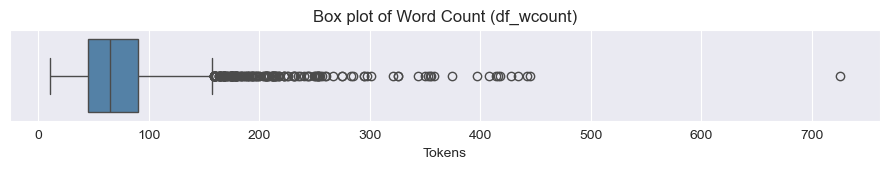

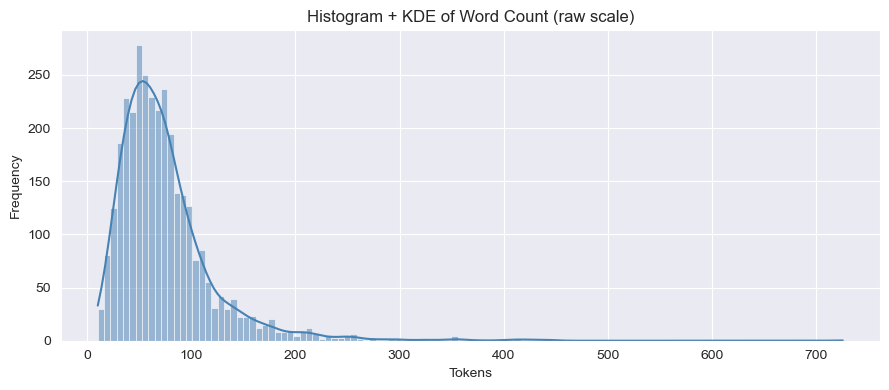

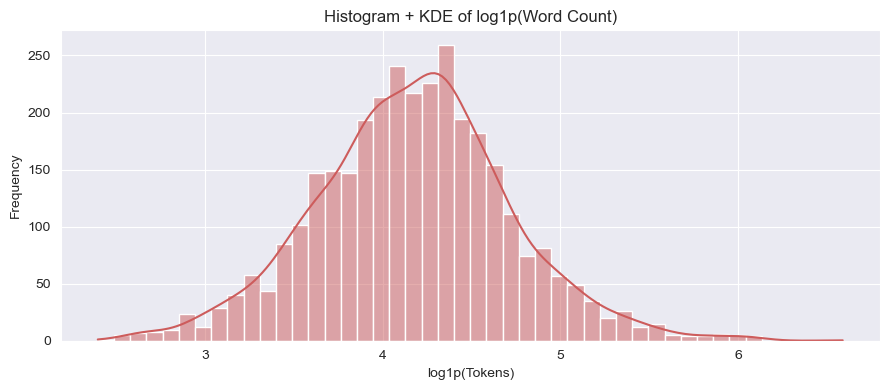

In [5]:
# Select the series
series = df_wcount['Word Count'].dropna()

# Summary stats
mean_val = series.mean()
std_val = series.std(ddof=1)  # sample standard deviation
desc = series.describe()  # count, mean, std, min, 25%, 50%, 75%, max

print('Descriptive statistics for Word Count:')
print(f"- Count: {int(desc['count'])}")
print(f"- Mean: {mean_val:.2f}")
print(f"- Std (sample): {std_val:.2f}")
print(f"- Min: {int(desc['min'])}")
print(f"- Q1 (25%): {desc['25%']:.2f}")
print(f"- Median (50%): {desc['50%']:.2f}")
print(f"- Q3 (75%): {desc['75%']:.2f}")
print(f"- Max: {int(desc['max'])}")

# IQR-based outlier detection
q1, q3 = series.quantile([0.25, 0.75])
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

outlier_mask = (series < lower_fence) | (series > upper_fence)
outliers = (
    df_wcount.loc[outlier_mask, ['Text ID', 'Word Count']]
    .sort_values('Word Count')
    .reset_index(drop=True)
)

print(f"\nIQR outlier thresholds:")
print(f"- Lower fence: {lower_fence:.2f}")
print(f"- Upper fence: {upper_fence:.2f}")
print(f"Outliers found: {len(outliers)}")
display(outliers)

# Box plot
plt.figure(figsize=(9, 1.8))
sns.boxplot(x=series, color='steelblue')
plt.title('Box plot of Word Count (df_wcount)')
plt.xlabel('Tokens')
plt.tight_layout()

# Saving the plot
plt.savefig(f"{output_directory}/cl_st1_ph2_fernanda_boxplot.png", dpi=300)

plt.show()

# Raw scale: Histogram + KDE
plt.figure(figsize=(9, 4))
sns.histplot(series, bins='auto', kde=True, color='steelblue')
plt.title('Histogram + KDE of Word Count (raw scale)')
plt.xlabel('Tokens')
plt.ylabel('Frequency')
plt.tight_layout()

# Saving the plot
plt.savefig(f"{output_directory}/cl_st1_ph2_fernanda_histogram.png", dpi=300)

plt.show()

# Log scale via transformation: Histogram + KDE
log_series = np.log1p(series)  # log(1 + x) to handle zeros safely
plt.figure(figsize=(9, 4))
sns.histplot(log_series, bins='auto', kde=True, color='indianred')
plt.title('Histogram + KDE of log1p(Word Count)')
plt.xlabel('log1p(Tokens)')
plt.ylabel('Frequency')
plt.tight_layout()

# Saving the plot
plt.savefig(f"{output_directory}/cl_st1_ph2_fernanda_histogram_log_scale.png", dpi=300)

plt.show()

### Import `sas/dates.txt` into a DataFrame

In [6]:
# Define the column names
column_names = ['Text ID', 'Year 1', 'Year 2']

# Import the file
df_dates = pd.read_csv(f"{input_directory}/dates.txt", sep=' ', header=None, names=column_names)

In [7]:
df_dates

,Text ID,Year 1,Year 2
0,fat000000,22,23.0
1,fat000001,22,23.0
2,fat000002,22,23.0
3,fat000003,22,23.0
4,fat000004,22,23.0
...,...,...,...
3249,fat003249,23,24.0
3250,fat003250,23,24.0
3251,fat003251,23,24.0
3252,fat003252,23,24.0


In [8]:
# Make 'Year 2' equal to 'Year 1' where 'Year 2' is NaN
df_dates['Year 2'] = df_dates['Year 2'].fillna(df_dates['Year 1'])

# Convert 'Year 1' and 'Year 2' to pandas datetime as 4-digit years of the current century
current_century = (pd.Timestamp.now().year // 100) * 100
for col in ['Year 1', 'Year 2']:
    years_int = pd.to_numeric(df_dates[col], errors='coerce').astype('Int64')
    full_years = years_int.where(years_int >= 100, years_int + current_century)
    df_dates[col] = pd.to_datetime(full_years.astype('float').astype('Int64').astype(str), format='%Y', errors='coerce')

# Format as 4-digit year strings (keeping dtype datetime for operations, but show formatted)
df_dates['Year 1'] = df_dates['Year 1'].dt.strftime('%Y')
df_dates['Year 2'] = df_dates['Year 2'].dt.strftime('%Y')

df_dates

,Text ID,Year 1,Year 2
0,fat000000,2022,2023
1,fat000001,2022,2023
2,fat000002,2022,2023
3,fat000003,2022,2023
4,fat000004,2022,2023
...,...,...,...
3249,fat003249,2023,2024
3250,fat003250,2023,2024
3251,fat003251,2023,2024
3252,fat003252,2023,2024


### Combining the `df_dates` and `df_wcount` DataFrames into `df_corpus_design` DataFrame

In [9]:
# Merge the DataFrames on 'Text ID'
merged_df = pd.merge(df_dates, df_wcount, on='Text ID')

# Group by ('Year 1', 'Year 2') to get 'Text Count' and 'Word Count'
df_corpus_design = merged_df.groupby(['Year 1', 'Year 2']).agg({
    'Text ID': 'count',
    'Word Count': 'sum'
}).reset_index()

# Rename columns to match the requirements
df_corpus_design.rename(columns={'Text ID': 'Text Count'}, inplace=True)

# Append totals row at the bottom
totals_row = {
    'Year 1': 'Total',
    'Year 2': '',
    'Text Count': df_corpus_design['Text Count'].sum(),
    'Word Count': df_corpus_design['Word Count'].sum()
}
df_corpus_design = pd.concat([df_corpus_design, pd.DataFrame([totals_row])], ignore_index=True)

df_corpus_design

,Year 1,Year 2,Text Count,Word Count
0,2022,2022,268,15555
1,2022,2023,486,34740
2,2023,2023,832,69373
3,2023,2024,418,31477
4,2024,2024,402,31145
5,2024,2025,351,28564
6,2025,2025,213,16524
7,2026,2026,284,15992
8,Total,,3254,243370


### Create a LaTeX table

In [12]:
title = 'Text and Word Count by Year Range'
filename = 'df_corpus_design'

In [13]:
caption = title
label = f"tab:{filename}"
tex_filename = f"{filename}.tex"

In [14]:
tex_table = df_corpus_design.to_latex(longtable=True, caption=caption, label=label)

In [15]:
with open(f"{output_directory}/{tex_filename}", 'w', encoding='utf8', newline='\n') as file:
    file.write(tex_table)